In [39]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands

In [60]:
# two egde variances 0.5 and 1, only Falserejection, 10k nsim, name=simulation_results_20260122_1816.csv"
# one edge var at 1, 20k nsim, name=simulation_results_20260123_1022.csv
# sigma 05, 099 simulation_results_20260124_2058
results = pd.read_csv("simulation_results_20260128_1518.csv")

In [62]:
results["method"] = results["args"].apply(
    lambda x: re.search(r"'method':.*?\.(\w+?)(?=Test)", x).group(1).lower()
)
results["sigma"] = results["args"].apply(
    lambda x: re.search(r"'sigma':\s*(\d+\.?\d*)", x).group(1)
)
results["dgp"] = results["args"].apply(
    lambda x: re.search(r"(?<=\.)\w+(?='>)", x).group(0).lower()
)
results["solver"] = results["args"].apply(
    lambda x: re.search(r"'solver':\s*<function\s+(\w+)", x).group(1).lower()
)

In [91]:
results[
    (results["dgp"] == "gaussiannetwork")
    & (results["sigma"] == "0")
    & (results["solver"] == "mle_gaussian")
]["FalseRejection"].mean()

np.float64(0.04888888888888889)

In [63]:
# based on dgp
results_gaussian = results[(results["dgp"] == "gaussiannetwork")].copy()
results_bernoulli = results[(results["dgp"] == "bernoullinetwork")].copy()

# based on sigma + dgp
results_null_gaussian = results_gaussian[(results_gaussian["sigma"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["sigma"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[
    (results_gaussian["sigma"] == "0.01")
].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["sigma"] == "0.1")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["sigma"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.5")
].copy()
results_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.01")
].copy()
results_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.1")
].copy()

# based on sigma + method + dgp
results_llk_ratio_null_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0")
].copy()
results_llk_ratio_alt_001_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.01")
].copy()
results_llk_ratio_alt_05_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.5")
].copy()
results_llk_ratio_alt_01_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.1")
].copy()

results_rv_null_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation") & (results_gaussian["sigma"] == "0")
].copy()
results_rv_alt_001_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.01")
].copy()
results_rv_alt_05_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.5")
].copy()
results_rv_alt_01_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.1")
].copy()

results_llk_ratio_null_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0")
].copy()
results_llk_ratio_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.01")
].copy()
results_llk_ratio_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.5")
].copy()
results_llk_ratio_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.1")
].copy()

results_rv_null_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0")
].copy()
results_rv_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.01")
].copy()
results_rv_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.5")
].copy()
results_rv_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.1")
].copy()

In [64]:
# for the null extract the false rejection to study type I error

agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

In [65]:
# for alternative extract the true rejection to study power
agg_alt_001_gaussian = aggregate_results(
    results_alt_001_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_alt_05_gaussian = aggregate_results(
    results_alt_05_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_alt_01_gaussian = aggregate_results(
    results_alt_01_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

agg_alt_001_bernoulli = aggregate_results(
    results_alt_001_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_alt_05_bernoulli = aggregate_results(
    results_alt_05_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_alt_01_bernoulli = aggregate_results(
    results_alt_01_bernoulli,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

In [66]:
agg_llk_ratio_null_gaussian = aggregate_results(
    results_llk_ratio_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_rv_null_gaussian = aggregate_results(
    results_rv_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

agg_llk_ratio_alt_001_gaussian = aggregate_results(
    results_llk_ratio_alt_001_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_llk_ratio_alt_05_gaussian = aggregate_results(
    results_llk_ratio_alt_05_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_llk_ratio_alt_01_gaussian = aggregate_results(
    results_llk_ratio_alt_01_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

agg_rv_alt_001_gaussian = aggregate_results(
    results_rv_alt_001_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_rv_alt_05_gaussian = aggregate_results(
    results_rv_alt_05_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)
agg_rv_alt_01_gaussian = aggregate_results(
    results_rv_alt_01_gaussian,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "solver"],
)

## Plots

**Ensure type I error is controlled at 5%**

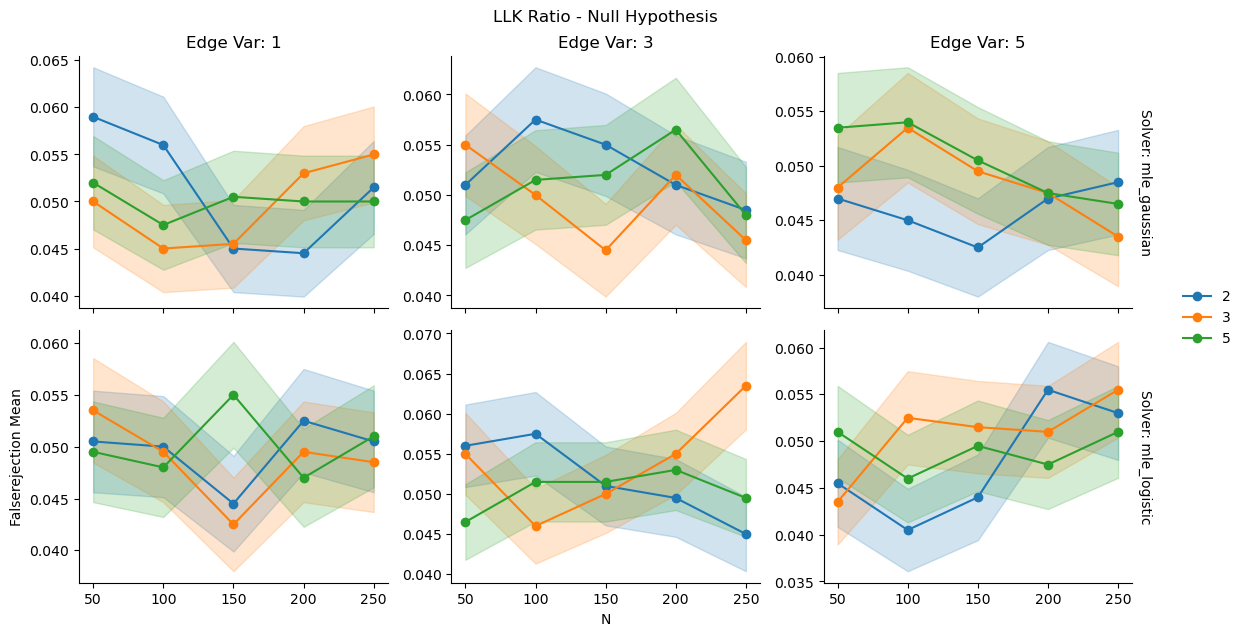

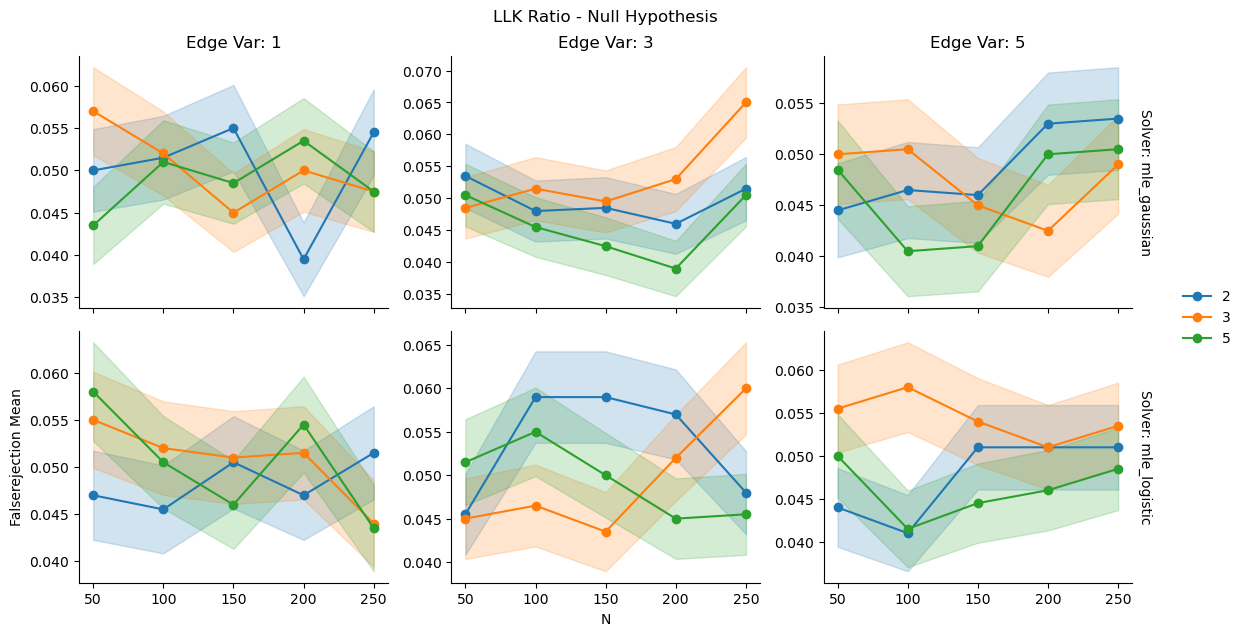

In [77]:
plot_grid(
    grouped_stats=agg_null_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Null Hypothesis",
)

plot_grid(
    grouped_stats=agg_null_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Null Hypothesis",
)

**Study Power**

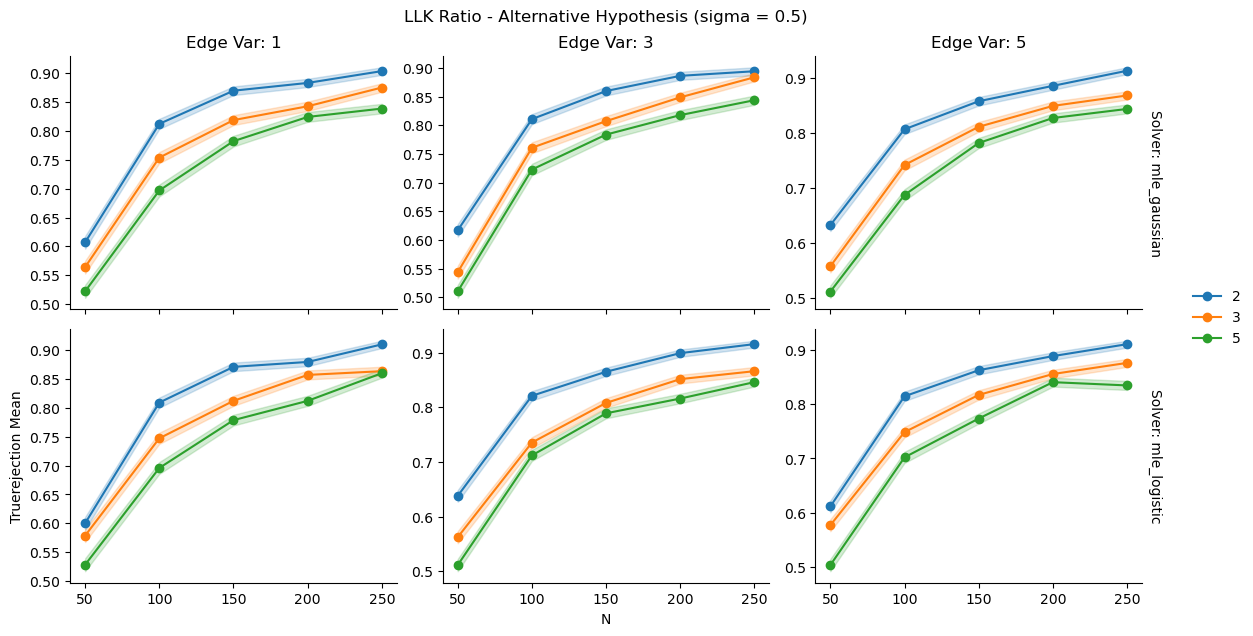

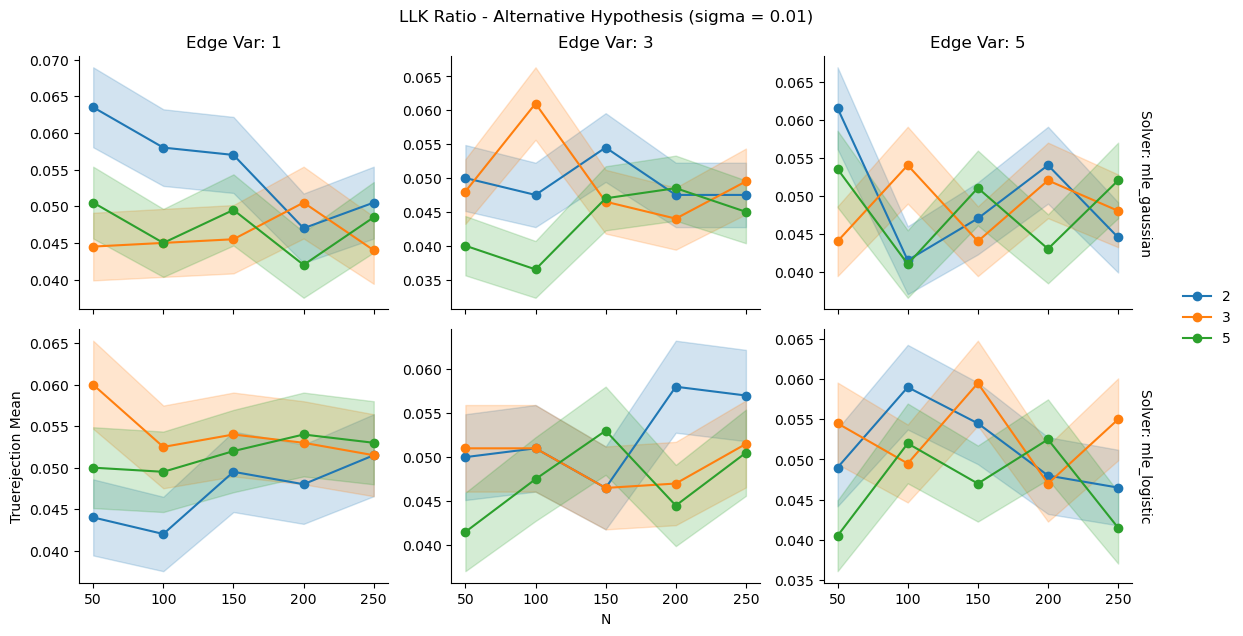

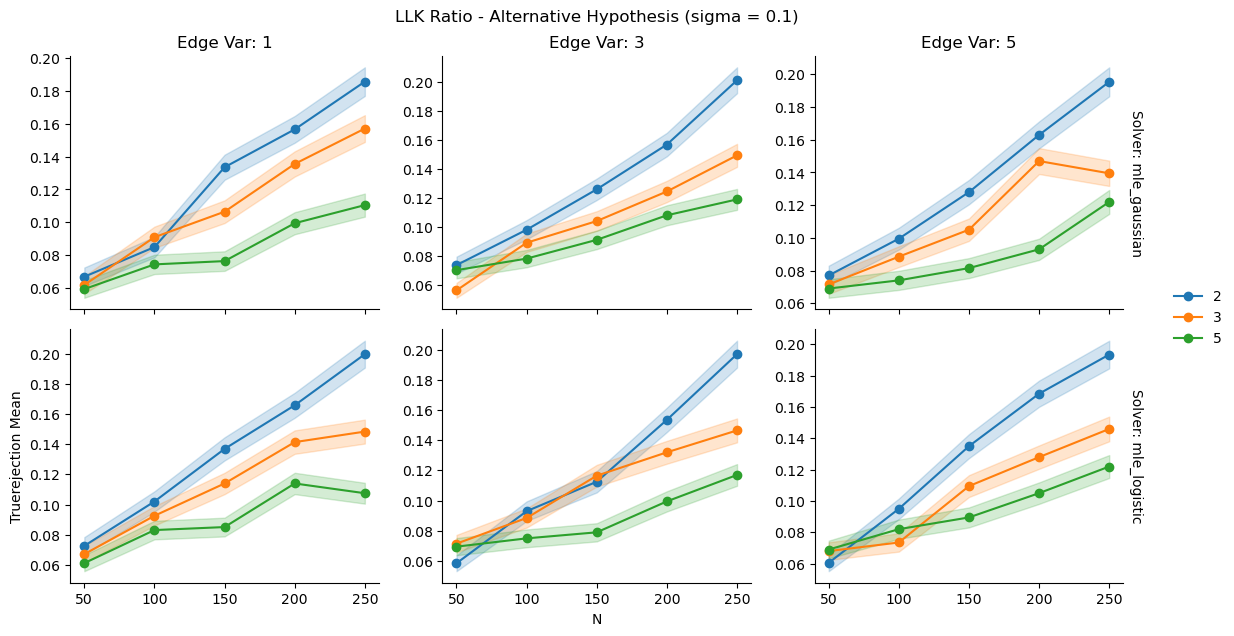

In [74]:
plot_grid(
    grouped_stats=agg_alt_05_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Alternative Hypothesis (sigma = 0.5)",
)

plot_grid(
    grouped_stats=agg_alt_001_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Alternative Hypothesis (sigma = 0.01)",
)

plot_grid(
    grouped_stats=agg_alt_01_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["k", "edge_var", "solver"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Alternative Hypothesis (sigma = 0.1)",
)

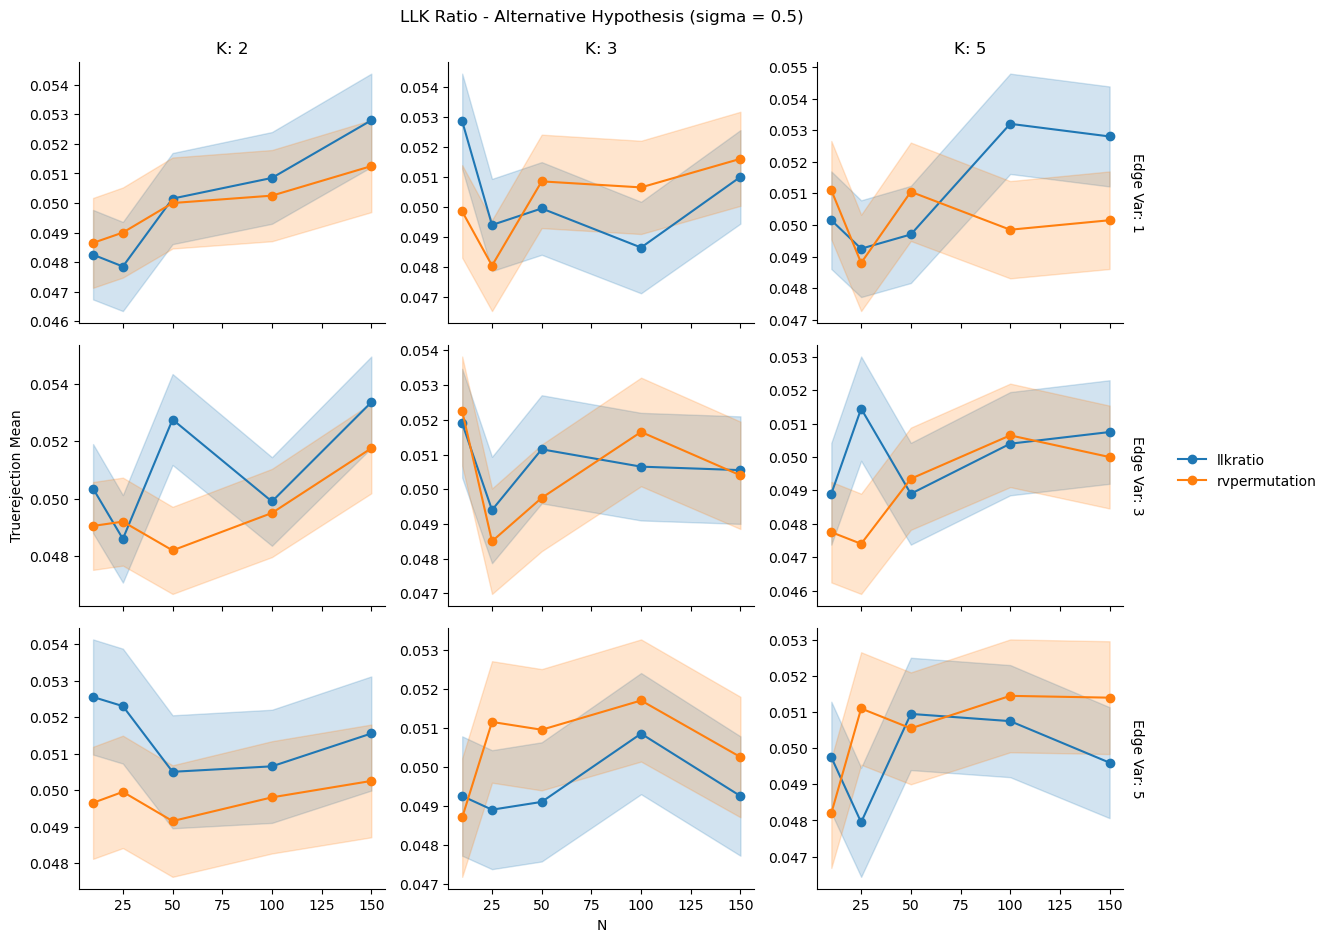

In [ ]:
plot_grid(
    grouped_stats=agg_alt_001,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "k", "edge_var"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Alternative Hypothesis (sigma = 0.5)",
)

In [ ]:
plot_grid(
    grouped_stats=agg_llk_ratio_alternative,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["edge_var", "k"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="LLK Ratio - Alternative Hypothesis (sigma-0.5)",
)

plot_grid(
    grouped_stats=agg_rv_alternative,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["edge_var", "k"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="RV permutation - Alternative Hypothesis (sigma-0.5)",
)

NameError: name 'agg_llk_ratio_alternative' is not defined